In [2]:
import datetime, calendar, glob, os, requests, pickle

import pickle as pkl
import geopandas as gpd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.colors as mcolors
import networkx as nx

from matplotlib import cm
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.transforms import ScaledTranslation

from datetime import datetime

from shapely.geometry import box
from shapely.ops import unary_union

plt.rcParams["legend.handlelength"] = 1
plt.rcParams["legend.handleheight"] = 1.125
plt.rcParams["font.family"] = "Avenir"

path_to_data = "/Users/Guille/Desktop/dynamic_update/data"
path_to_images = "/Users/Guille/Desktop/dynamic_update/images"
path_to_validation = "/Users/Guille/Desktop/dynamic_update/validation"

# Loading color palette
palette_ = pd.read_csv(path_to_data + "/palette.csv")
print(palette_)

# Loading Texas map
TX_ = gpd.read_file(path_to_data + "/maps/TX/State.shp")

T = 288
resource = 'wind'

      miro      ibm
0  #013396  #648FFF
1  #B1C06E  #785EF0
2  #056534  #DC267F
3  #F80202  #FE6100
4  #FDD906  #FFB000
5  #FCF795      NaN
6  #CCEDFF      NaN
7  #FDD60B      NaN
8  #FCE9D0      NaN


In [3]:
# url = "https://services2.arcgis.com/z5VWEXupJpBJnZRq/ArcGIS/rest/services/WECC_Balancing_Authorities/FeatureServer/0/query"

# params = {"where": "1=1",
#           "outFields": "*",
#           "outSR": "4326",
#           "f": "geojson"}

# data = requests.get(url, params=params).json()

# path_to_data = "/Users/Guille/Desktop/map/"
# WECC_ = gpd.GeoDataFrame.from_features(data["features"], crs="EPSG:4326")

# # Save
# WECC_.to_file(path_to_data + "/WECC.shp", 
#               driver="ESRI Shapefile")

In [4]:
# Load
TX_ = gpd.read_file(path_to_data + "/maps/Texas_County_Boundaries_Detailed/Texas_County_Boundaries_Detailed.shp")
TX_ = TX_[['CNTY_NM', 
           'geometry']].rename(columns={'CNTY_NM': 'County'}).to_crs(epsg=4326)

df_ = pd.read_excel(path_to_data + "/gridstatus/meta/Wind_Solar_Regions_to_County.xlsx")

# Merge region info
TX_ = TX_.merge(df_, on="County", how="left")

# Dissolve once (this is enough)
TX_ = TX_.dissolve(by="Wind Region", as_index=False)

# Fix topology
TX_["geometry"] = TX_.buffer(0)

# Optional: rename AFTER everything
TX_ = TX_.rename(columns={'Wind Region': 'region'})

In [5]:
# url = "https://services3.arcgis.com/fwwoCWVtaahwlvxO/arcgis/rest/services/ERCOT_Load_Zones/FeatureServer/7/query"

# params = {"where": "1=1",
#           "outFields": "*",
#           "outSR": "4326",
#           "f": "geojson"}

# data = requests.get(url, params=params).json()

# ERCOT_ = gpd.GeoDataFrame.from_features(data["features"], crs="EPSG:4326")

# # clean columns
# ERCOT_ = ERCOT_.drop(columns=['OBJECTID',
#                               'STATEFP',
#                               'STUSPS',
#                               'AFFGEOID',
#                               'STATENS',
#                               'ALAND',
#                               'AWATER',
#                               'LSAD',
#                               'GEOID',
#                               'Shape__Area',
#                               'Shape__Length',
#                               'ZONE_NAME'])

# ERCOT_ = ERCOT_.rename(columns={'NAME': 'hub'})

# # Panhandle extraction
# panhandle_bbox = box(-103.5, 34.0, -100.0, 36.5)

# panhandle = ERCOT_[ERCOT_["hub"] == "West"].intersection(panhandle_bbox)
# panhandle_union = panhandle.unary_union.buffer(0)

# # Remove from West
# west = ERCOT_[ERCOT_["hub"] == "West"].copy()
# west["geometry"] = west.geometry.difference(panhandle_union)

# # clean west
# west = west[~west.is_empty]

# # Create Panhandle
# panhandle_gdf = gpd.GeoDataFrame({"hub": ["Panhandle"]},
#                                  geometry=[panhandle_union],
#                                  crs=ERCOT_.crs)

# # Combine
# gdf_no_west = ERCOT_[ERCOT_["hub"] != "West"]

# ERCOT_ = gpd.pd.concat([gdf_no_west, west, panhandle_gdf],
#                        ignore_index=True)

# # Save
# ERCOT_.to_file(path_to_data + "/maps/ERCOT_load_zones.shp", 
#                driver="ESRI Shapefile")

In [6]:
# Loading and processing wind assets in ERCOT

B_ = pd.read_excel(path_to_data + "/gridstatus/meta/Jan_2026_generators.xlsx", 
                   sheet_name="Operating")

B_ = B_.loc[B_['Balancing Authority Code'] == 'ERCO'].reset_index(drop = True)
print(B_.shape)

B_ = B_[['Plant Name', 
         'Technology',
         'Balancing Authority Code', 
         'Nameplate Capacity (MW)',
         'Latitude', 
         'Longitude', 
         'Operating Month', 
         'Operating Year']]

B_ = B_.loc[B_['Technology'] == 'Onshore Wind Turbine'].reset_index(drop = True)

B_ = B_.sort_values(["Operating Year", 
                     "Operating Month"], ascending=[True, True])

B_ = B_.drop(columns = ['Technology', 
                        'Balancing Authority Code'])

B_ = gpd.GeoDataFrame(B_, 
                      geometry=gpd.points_from_xy(B_["Longitude"], B_["Latitude"]),
                      crs="EPSG:4326")
    
B_ = gpd.sjoin(B_, TX_[["region", "geometry"]],
               how="left",
               predicate="within")

B_ = B_.drop(columns = ['geometry', 
                        'index_right']).reset_index(drop = True)

print(B_.loc[B_["region"].isna()])
print(B_)

Operating
Canceled or Postponed
Operating_PR
Planned
Planned_PR
Retired
Retired_PR
(2165, 37)
Empty DataFrame
Columns: [Plant Name, Nameplate Capacity (MW), Latitude, Longitude, Operating Month, Operating Year, region]
Index: []
                         Plant Name Nameplate Capacity (MW)   Latitude  \
0    Big Spring Wind Power Facility                    34.3  32.207500   
1         NWP Indian Mesa Wind Farm                    82.5  30.931467   
2        King Mountain Wind Ranch 1                     278  31.209200   
3              Woodward Mountain II                      78  30.951400   
4               Woodward Mountain I                      82  30.951400   
..                              ...                     ...        ...   
204         Prairie Switch Wind LLC                   163.2  29.091900   
205                       Hart Wind                   166.4  34.378546   
206                  Lane City Wind                   202.5  29.209729   
207                  Monte Cris

In [7]:
# Define ERCOT regions as a graph

regions_ = TX_['region'].unique()

adjacent_regions_ = {"Coastal": {'Graph': [0, 1, 3], 'Order': [0, 2, 1]},
                     "North": {'Graph': [0, 1, 2, 3, 4], 'Order': [2, 0, 2, 2, 1]},
                     "Panhandle": {'Graph':  [1, 2, 4], 'Order': [2, 0, 1]},
                     "South": {'Graph':  [0, 1, 3, 4], 'Order': [1, 2, 0, 1]},
                     "West": {'Graph':  [1, 2, 3, 4], 'Order': [2, 1, 1, 0]}}

edges_ = [("Panhandle", "Panhandle", 0),
          ("Panhandle", "North", 2),
          ("Panhandle", "West", 1),
          ("North", "North", 0),
          ("North", "Coastal", 2),
          ("North", "South", 2),
          ("North", "West", 1),
          ("South", "South", 0),
          ("South", "Coastal", 1),
          ("South", "West", 2),
          ("Coastal", "Coastal", 0),
          ("West", "West", 0)]

df_edges_ = pd.DataFrame(edges_, columns=["source", "target", "order"])

region_coords_ = TX_.copy()

# Step 2: compute centroids in projected space
centroids_proj = region_coords_.to_crs(epsg=3857).geometry.centroid

# Step 3: bring centroids back to lat/lon
centroids  = centroids_proj.to_crs(TX_.crs)

region_coords_["lon"] = centroids.x.values
region_coords_["lat"] = centroids.y.values

region_coords_ = region_coords_[["region", "lat", "lon"]]
print(region_coords_)

      region        lat         lon
0    Coastal  28.200441  -96.490475
1      North  32.153264  -96.305561
2  Panhandle  35.017659 -101.588859
3      South  29.231469  -98.177359
4       West  31.709041 -101.884897


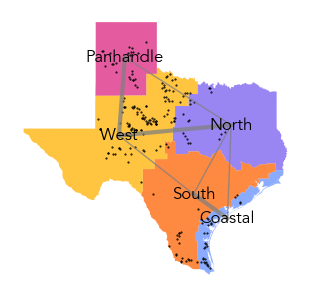

In [8]:
fig, ax = plt.subplots(figsize=(3.75, 3.75))

for region, i in zip(regions_, range(len(regions_))):
    TX_.iloc[[i]].plot(ax=ax,
                       fc=palette_['ibm'].iloc[i],
                       ec='None',
                       lw=0,
                       alpha=0.75)

ax.scatter(B_["Longitude"], B_["Latitude"],
           c='k',
           marker = 'o',
           s = .25)

_G = nx.from_pandas_edgelist(df_edges_.loc[df_edges_['order'] == 1], "source", "target")

for u, v, d in _G.edges(data=True):
    x_ = region_coords_.loc[region_coords_['region'] == u, ['lon', 'lat']].to_numpy()[0]
    y_ = region_coords_.loc[region_coords_['region'] == v, ['lon', 'lat']].to_numpy()[0]

    ax.plot([x_[0], y_[0]], [x_[1], y_[1]],
            lw=3,
            c='gray',
            #marker = 'o',
            #ms = 5.,
            alpha=.75)

_G = nx.from_pandas_edgelist(df_edges_.loc[df_edges_['order'] == 2], "source", "target")

for u, v, d in _G.edges(data=True):
    x_ = region_coords_.loc[region_coords_['region'] == u, ['lon', 'lat']].to_numpy()[0]
    y_ = region_coords_.loc[region_coords_['region'] == v, ['lon', 'lat']].to_numpy()[0]

    ax.plot([x_[0], y_[0]], [x_[1], y_[1]],
            lw=1.,
            c='gray',
            #marker = 'o',
            #ms = 5.,
            alpha=.75)
    
for region in region_coords_['region'].unique():
    x_ = region_coords_.loc[region_coords_['region'] == region, ['lon', 'lat']].to_numpy()[0]
    
    ax.text(x_[0], x_[1], region,
            ha="center",
            va="center",
            fontsize=12,
            weight="bold")

ax.set_axis_off()

plt.savefig(path_to_images + "/TX_zones.pdf", 
            bbox_inches = "tight")

plt.show()

In [9]:
# Define cumulative wind capacity over time by ERCOT region

B_lz_ = B_.groupby(['region', 
                    'Operating Month', 
                    'Operating Year']).agg({'Nameplate Capacity (MW)': 'sum'}).reset_index(drop = False)

B_lz_["date"] = pd.to_datetime(dict(year=B_lz_["Operating Year"].astype(int),
                                    month=B_lz_["Operating Month"].astype(int),
                                    day=1))

B_lz_ = B_lz_.drop(columns = ["Operating Year", 
                              "Operating Month"])

B_lz_ = B_lz_.sort_values(["region", 
                           "date"]).reset_index(drop = True)

B_lz_["Nameplate Capacity (MW)"] = pd.to_numeric(B_lz_["Nameplate Capacity (MW)"])
B_lz_ = B_lz_.rename(columns = {'Nameplate Capacity (MW)': 'capacity_mw'})

# full monthly range across your dataset
full_dates = pd.date_range(start=B_lz_["date"].min(),
                           end=B_lz_["date"].max(),
                           freq="MS")   # Month Start

# 2. full grid: region × date
idx = pd.MultiIndex.from_product([B_lz_["region"].unique(), full_dates],
                                 names=["region", "date"])

# 3. reindex properly
B_lz_full_ = B_lz_.set_index(["region", "date"]).reindex(idx).reset_index()

# 4. fill missing capacity
B_lz_full_["capacity_mw"] = B_lz_full_["capacity_mw"].fillna(0)

# 5. cumulative sum
B_lz_full_ = B_lz_full_.sort_values(["region", "date"])

B_lz_full_["cum_capacity_mw"] = B_lz_full_.groupby("region")["capacity_mw"].cumsum()

# Extra. cumulative sum
B_lz_ = B_lz_.sort_values(["region", "date"])
B_lz_["cum_capacity_mw"] = B_lz_.groupby("region")["capacity_mw"].cumsum()

B_lz_full_ = B_lz_full_.merge(region_coords_,
                              on="region",
                              how="left")

B_lz_full_.to_csv(path_to_data + "/gridstatus/meta/ERCOT_region.csv", 
                  index=False)

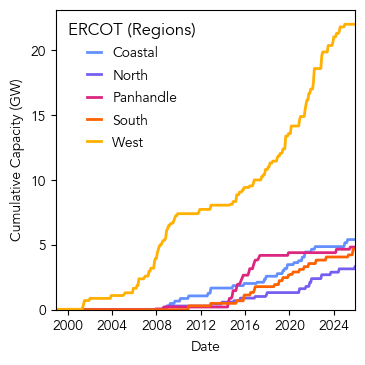

In [10]:
plt.figure(figsize = (3.75, 3.75))

for region, i in zip(regions_, range(len(regions_))):
        
    plt.plot(B_lz_full_.loc[B_lz_full_['region'] == region, 'date'],
             B_lz_full_.loc[B_lz_full_['region'] == region, 'cum_capacity_mw']/1000.,
             label=region,
             color=palette_['ibm'].iloc[i], 
             lw=2)

plt.legend(title="ERCOT (Regions)", 
           frameon = False, 
           title_fontsize=12, 
           fontsize = 10)

plt.xlabel("Date")
plt.ylabel("Cumulative Capacity (GW)")
plt.xlim(B_lz_full_['date'].min(), B_lz_full_['date'].max())
plt.ylim(0, )
plt.tight_layout()

plt.savefig(path_to_images + "/TX_zones_capacity.pdf", 
            bbox_inches = "tight")

plt.show()

In [11]:
# Workflow break
B_lz_ = pd.read_csv(path_to_data + "/gridstatus/meta/ERCOT_region.csv")

B_lz_["region"] = B_lz_["region"].str.lower()
B_lz_["date"] = pd.to_datetime(B_lz_["date"]).dt.strftime("%Y-%m")

regions_ = ['coastal', 
            'north',
            'panhandle',
            'south',
            'west']

In [12]:
n_horizons = 48

# reshape capacity to wide format (one column per region)
B_lz_['date'] = B_lz_['date'].astype(str)
cap_wide_ = B_lz_.pivot(index='date', columns='region', values='cum_capacity_mw')
cap_wide_ = cap_wide_.rename(columns=lambda r: f'cap_{r}')
cap_wide_ = cap_wide_.reset_index()
cap_wide_.columns.name = None

ac_ = pd.read_csv(path_to_data + "/gridstatus/ac_2023-01_2025-12.csv", index_col = 0)
fc_ = pd.read_csv(path_to_data + "/gridstatus/fc_2023-01_2025-12.csv")

ac_ = ac_[['interval_start_utc', 
           'gen_panhandle',
           'gen_coastal',
           'gen_south',
           'gen_west',
           'gen_north']]

# Interpolate NaNs
ac_['gen_panhandle'] = ac_['gen_panhandle'].interpolate(method='linear')
ac_['gen_coastal'] = ac_['gen_coastal'].interpolate(method='linear')
ac_['gen_south'] = ac_['gen_south'].interpolate(method='linear')
ac_['gen_west'] = ac_['gen_west'].interpolate(method='linear')
ac_['gen_north'] = ac_['gen_north'].interpolate(method='linear')

fc_ = fc_[['interval_start_utc', 
           'publish_time_utc',
           'stwpf_panhandle',
           'stwpf_coastal',
           'stwpf_south',
           'stwpf_west',
           'stwpf_north']]

counts_ = fc_.groupby('publish_time_utc').size()
fc_ = fc_.loc[fc_['publish_time_utc'].isin(counts_[counts_ == n_horizons].index)]

ac_ = ac_.sort_values("interval_start_utc").reset_index(drop=True)
fc_ = fc_.sort_values(["publish_time_utc", "interval_start_utc"]).reset_index(drop=True)
df_ = fc_.merge(ac_, on = ['interval_start_utc'], how = 'left')
print(ac_.shape, fc_.shape, df_.shape)

df_['date'] = pd.to_datetime(df_['interval_start_utc'], utc=True).dt.strftime('%Y-%m')

df_ = df_.merge(cap_wide_, on = ['date'], how = 'left')

df_ = df_.interpolate(method='linear').ffill()

# Generation forecast to capacity factor forecast
df_['stwpf_panhandle'] = df_['stwpf_panhandle']/df_['cap_panhandle']
df_['stwpf_coastal'] = df_['stwpf_coastal']/df_['cap_coastal']
df_['stwpf_south'] = df_['stwpf_south']/df_['cap_south']
df_['stwpf_west'] = df_['stwpf_west']/df_['cap_west']
df_['stwpf_north'] = df_['stwpf_north']/df_['cap_north']

print(df_['stwpf_panhandle'].min(), df_['stwpf_panhandle'].max())
print(df_['stwpf_coastal'].min(), df_['stwpf_coastal'].max())
print(df_['stwpf_south'].min(), df_['stwpf_south'].max())
print(df_['stwpf_west'].min(), df_['stwpf_west'].max())
print(df_['stwpf_north'].min(), df_['stwpf_north'].max())

df_['gen_panhandle'] = df_['gen_panhandle']/df_['cap_panhandle']
df_['gen_coastal'] = df_['gen_coastal']/df_['cap_coastal']
df_['gen_south'] = df_['gen_south']/df_['cap_south']
df_['gen_west'] = df_['gen_west']/df_['cap_west']
df_['gen_north'] = df_['gen_north']/df_['cap_north']

print(df_['gen_panhandle'].min(), df_['gen_panhandle'].max())
print(df_['gen_coastal'].min(), df_['gen_coastal'].max())
print(df_['gen_south'].min(), df_['gen_south'].max())
print(df_['gen_west'].min(), df_['gen_west'].max())
print(df_['gen_north'].min(), df_['gen_north'].max())

idx_ = ((df_['stwpf_panhandle'] > 1)
        | (df_['stwpf_coastal'] > 1)
        | (df_['stwpf_south'] > 1)
        | (df_['stwpf_west'] > 1)
        | (df_['stwpf_north'] > 1)
        | (df_['gen_panhandle'] > 1)
        | (df_['gen_coastal'] > 1)
        | (df_['gen_south'] > 1)
        | (df_['gen_west'] > 1)
        | (df_['gen_north'] > 1))

#print(df_.loc[idx_, 'publish_time_utc'].unique())
print(df_.shape)
df_ = df_.loc[~df_['publish_time_utc'].isin(df_.loc[idx_, 'publish_time_utc'].unique())]
print(df_.shape)

#df_.to_csv(path_to_data + "/gridstatus/processed_2023-01_2025-12.csv")

(27048, 6) (1207536, 7) (1207536, 12)
0.0 1.6810421538397864
0.0 1.820730880631047
0.0 1.5570223959485705
0.0 1.5994967365088595
0.0 1.6755839045443008
2.727024815925825e-05 1.6864944095991274
0.0 0.8063988003533206
0.0 0.7765543181650565
1.6044889015210553e-05 0.9926020023142326
0.0 0.8942076786243699
(1207536, 18)
(1205088, 18)


In [13]:
# # WGRPP: Wind Generation Resource Production Potential
# # STWPF: Short-Term Wind Power Forecast
# # COP_HSL: Current Operating Plan High Sustainable Limit

# fc_type = 'stwpf'
# print(regions_)
# fc_regions_ = [f'{fc_type}_{region}' for region in regions_]

# n_regions = len(fc_regions_)
# n_horizon_hours = 48
# n_day_hours = 24

# # Get all CSV files
# path_to_file = os.path.join(path_to_data, "gridstatus", "fc_2023-01_2025-12.csv")

# fc_ = pd.read_csv(path_to_file)

# fc_['date'] = pd.to_datetime(
#     fc_['interval_start_local'],
#     errors='coerce',
#     utc=True
# ).dt.strftime('%Y-%m')

# fc_ = fc_[['interval_start_local', 
#            'interval_start_utc', 
#            'interval_end_local',
#            'interval_end_utc', 
#            'publish_time_local', 
#            'publish_time_utc',
#            'date',
#            'stwpf_panhandle',
#            'stwpf_coastal',
#            'stwpf_south',
#            'stwpf_west',
#            'stwpf_north']]
# print(fc_.shape)


# # # merge into fc_
# # fc_ = fc_.merge(cap_wide_, left_on='date', right_index=True, how='left')

# # # Generation forecast to capacity factor forecast
# # fc_['stwpf_panhandle'] = fc_['stwpf_panhandle']/fc_['cap_panhandle']
# # fc_['stwpf_coastal'] = fc_['stwpf_coastal']/fc_['cap_coastal']
# # fc_['stwpf_south'] = fc_['stwpf_south']/fc_['cap_south']
# # fc_['stwpf_west'] = fc_['stwpf_west']/fc_['cap_west']
# # fc_['stwpf_north'] = fc_['stwpf_north']/fc_['cap_north']
# # print(fc_.shape)

# # Remove days with incomplete forecasts
# df_ = fc_[['interval_start_utc', 
#            'publish_time_utc']].copy()

# counts_ = df_.groupby('publish_time_utc').size()
# index_  = df_['publish_time_utc'].isin(counts_[counts_ == n_horizon_hours].index)

# df_ = df_[index_].reset_index(drop=True)
# fc_ = fc_[index_].reset_index(drop=True)
# n_days = fc_['publish_time_utc'].nunique()
# print(n_days, n_horions, n_regions, n_horizon_hours*n_days)

# # Vectorize datafremes
# dt_ = pd.to_datetime(fc_["interval_start_utc"], utc=True).to_numpy().reshape(n_days, n_horions)
# print(fc_[fc_regions_].to_numpy().shape)
# fc_ = fc_[fc_regions_].to_numpy()#.reshape(n_days, n_horizon_hours, n_regions)
# print(dt_.shape, fc_.shape)

# # # Put into DataFrame
# # df_ = pd.DataFrame({"time": pd.to_datetime(dt_[:, 0])})
# # df_["date"] = df_["time"].dt.floor("D")

# # # Keep only full days (24 hours)
# # counts_ = df_.groupby("date").size()
# # index_ = df_["date"].isin(counts_[counts_ == n_day_hours].index)

# # dt_fc_ = dt_[index_, :].reshape(-1, n_day_hours, n_horizon_hours)
# # fc_ = fc_[index_, :].reshape(-1, n_day_hours, n_horizon_hours, n_regions)
# # print(dt_fc_.shape, fc_.shape)

In [14]:
# fc_type = 'stwpf'
# n_horizon_hours = 48
# n_day_hours = 24

# print(regions_)
# fc_regions_ = [f'{fc_type}_{region}' for region in regions_]
# n_regions = len(fc_regions_)

# fc_ = pd.read_csv(os.path.join(path_to_data, "gridstatus", "fc_2023-01_2025-12.csv"))

# # Create monthly date key
# fc_['date'] = pd.to_datetime(
#     fc_['interval_start_local'],
#     errors='coerce',
#     utc=True
# ).dt.strftime('%Y-%m')

# # Keep only necessary columns
# fc_ = fc_[[
#     'interval_start_local',
#     'interval_start_utc',
#     'interval_end_local',
#     'interval_end_utc',
#     'publish_time_local',
#     'publish_time_utc',
#     'date',
#     'stwpf_panhandle',
#     'stwpf_coastal',
#     'stwpf_south',
#     'stwpf_west',
#     'stwpf_north'
# ]]


# B_lz_['date'] = B_lz_['date'].astype(str)

# cap_wide_ = B_lz_.pivot(index='date', columns='region', values='cum_capacity_mw')
# cap_wide_ = cap_wide_.rename(columns=lambda r: f'cap_{r}')

# fc_ = fc_.merge(cap_wide_, left_on='date', right_index=True, how='left')

# # Normalize to capacity factors
# for region in regions_:
#     fc_[f'{fc_type}_{region}'] = fc_[f'{fc_type}_{region}'] / fc_[f'cap_{region}']


# counts_ = fc_.groupby('publish_time_utc').size()

# fc_ = fc_[fc_['publish_time_utc'].isin(counts_[counts_ == n_horizon_hours].index)].copy()
# fc_ = fc_.sort_values(['publish_time_utc', 'interval_start_utc'])

# dt_fc_list_ = []
# fc_list_ = []
# for publish_time, df_group_ in fc_.groupby('publish_time_utc'):

#     # Safety check (should already be 48)
#     if len(df_group_) != n_horizon_hours:
#         continue

#     dt_fc_list_.append(pd.to_datetime(df_group_['interval_start_utc'], utc=True).to_numpy())
#     fc_list_.append(df_group_[fc_regions_].to_numpy())

# dt_fc_ = np.stack(dt_fc_list_)      # (n_forecasts, 48)
# fc_ = np.stack(fc_list_)            # (n_forecasts, 48, n_regions)

# df_ = pd.DataFrame({"time": pd.to_datetime(dt_fc_[:, 0])})
# df_["date"] = df_["time"].dt.floor("D")
# counts = df_.groupby("date").size()
# index_ = df_["date"].isin(counts[counts == n_day_hours].index)

# # Final reshape
# dt_fc_ = dt_fc_[index_, :].reshape(-1, n_day_hours, n_horizon_hours)
# fc_ = fc_[index_, :].reshape(-1, n_day_hours, n_horizon_hours, n_regions)
# print(dt_fc_.shape, fc_.shape)

In [15]:
# print(dt_fc_[204, 12, :])
# plt.figure()
# plt.plot(fc_[204, 12, :, 1].T)
# plt.ylim(0, 1)
# plt.show()

In [16]:
# # WGRPP: Wind Generation Resource Production Potential
# # STWPF: Short-Term Wind Power Forecast
# # COP_HSL: Current Operating Plan High Sustainable Limit

# # Loading and processing forecasted generation
# def _extract_date_from_name(file):
#     name = os.path.basename(file).replace(".csv", "")
#     name = os.path.basename(name).replace("fc_", "")
#     return datetime.strptime(name, "%Y-%m")  

# fc_type = 'stwpf'
# print(regions_)
# fc_regions_ = [f'{fc_type}_{region}' for region in regions_]

# # Get all CSV files
# fc_files_ = glob.glob(os.path.join(path_to_data + "/gridstatus/old", "fc*.csv"))

# # Sort files by date
# fc_files_sorted_ = sorted(fc_files_, key=_extract_date_from_name)

# print(fc_regions_)

# DT_fc_ = []
# FC_ = []
# for file in fc_files_sorted_:
#     print(file)

#     df_ = pd.read_csv(file)

#     for region, fc_region in zip(regions_, fc_regions_):

#         date = file.split('/')[-1].replace(".csv", "").replace("fc_", "")
#         idx_ = (B_lz_["region"] == region) & (B_lz_["date"] == date)

#         capacity_mw = B_lz_.loc[idx_, "cum_capacity_mw"].to_numpy()[0]
#         print(date, region, capacity_mw)

#         df_[fc_region] = df_[fc_region].to_numpy()/capacity_mw

#         dt_ = df_[['interval_start_utc', 
#                    'publish_time_utc']].copy()
        
#         fc_ = df_[fc_regions_].copy()
    
#         remove_publish_time_local_ = []
#         for publish_time_local in dt_['publish_time_utc'].unique():
#             idx_ = dt_['publish_time_utc'] == publish_time_local
#             if idx_.sum() != 48:
#                 remove_publish_time_local_.append(publish_time_local)
        
#         idx_ = dt_["publish_time_utc"].isin(remove_publish_time_local_)

#         dt_ = dt_[~idx_].reset_index(drop=True)
#         fc_ = fc_[~idx_].reset_index(drop=True)
#         print(fc_.shape, dt_.shape)


#     for publish_time_local in dt_['publish_time_utc'].unique():
#         idx_ = dt_['publish_time_utc'] == publish_time_local
    
#         DT_fc_.append(dt_.loc[idx_, 'interval_start_utc'].to_numpy())
#         FC_.append(fc_.loc[idx_, fc_regions_].to_numpy())

# DT_fc_ = np.stack(DT_fc_)
# FC_ = np.stack(FC_)
# print(DT_fc_.shape, FC_.shape)

# # Formatting forecasted generation structure

# # Put into DataFrame
# df_ = pd.DataFrame({"time": pd.to_datetime(DT_fc_[:, 0])})

# # Extract date (UTC-safe)
# df_["date"] = df_["time"].dt.floor("D")

# # Count hours per day
# counts = df_.groupby("date").size()

# # Keep only full days (24 hours)
# valid_days = counts[counts == 24].index
# idx_ = df_["date"].isin(valid_days)

# # Filter
# DT_fc_clean_ = DT_fc_[idx_, :].reshape(-1, 24, 48)
# FC_clean_ = FC_[idx_, :].reshape(-1, 24, 48, 5)
# print(DT_fc_clean_.shape, FC_clean_.shape)

In [17]:
# # Loading and processing actual generation
# fc_type = 'gen'

# fc_regions_ = [f'{fc_type}_{region}' for region in regions_]

# ac_ = pd.read_csv(path_to_data + "/gridstatus/ac_2023-01_2025-12.csv", index_col = 0)
# ac_["interval_start_utc"] = pd.to_datetime(ac_["interval_start_utc"])
# ac_ = ac_.loc[ac_["interval_start_utc"].dt.year < 2026]

# ac_ = ac_[[
#     'interval_start_utc', 
#     'interval_end_utc', 
#     'publish_time_utc',
#     'gen_panhandle',
#     'gen_coastal',
#     'gen_south',
#     'gen_west',
#    'gen_north'
# ]]

# ac_['date'] = pd.to_datetime(
#     ac_['interval_start_utc'],
#     errors='coerce',
#     utc=True
# ).dt.strftime('%Y-%m')
# print(ac_.isna().sum())

# # Interpolate NaNs
# ac_['gen_panhandle'] = ac_['gen_panhandle'].interpolate(method='linear')
# ac_['gen_coastal'] = ac_['gen_coastal'].interpolate(method='linear')
# ac_['gen_south'] = ac_['gen_south'].interpolate(method='linear')
# ac_['gen_west'] = ac_['gen_west'].interpolate(method='linear')
# ac_['gen_north'] = ac_['gen_north'].interpolate(method='linear')
# print(ac_.isna().sum())

# # merge into fc_
# ac_ = ac_.merge(cap_wide_, left_on='date', right_index=True, how='left')

# # Generation forecast to capacity factor forecast
# ac_['gen_panhandle'] = ac_['gen_panhandle']/ac_['cap_panhandle']
# ac_['gen_coastal'] = ac_['gen_coastal']/ac_['cap_coastal']
# ac_['gen_south'] = ac_['gen_south']/ac_['cap_south']
# ac_['gen_west'] = ac_['gen_west']/ac_['cap_west']
# ac_['gen_north'] = ac_['gen_north']/ac_['cap_north']

# dt_ = pd.to_datetime(ac_["interval_start_utc"], utc=True).to_numpy()
# ac_ = ac_[fc_regions_].to_numpy()
# print(dt_.shape, ac_.shape)

# n_span_hours = n_horizon_hours + n_day_hours
# print(n_span_hours)

# dt_ = np.lib.stride_tricks.sliding_window_view(dt_, window_shape=n_span_hours)[:-1, ...]
# ac_ = np.lib.stride_tricks.sliding_window_view(ac_, window_shape=(n_span_hours), axis=0)[:-1, ...]
# ac_ = np.swapaxes(ac_, 1, 2)
# print(dt_ac_.shape, ac_.shape)

# # Put into DataFrame
# df_ = pd.DataFrame({"time": pd.to_datetime(dt_[:, 0])})
# df_["date"] = df_["time"].dt.floor("D")

# # Keep only full days (24 hours)
# counts_ = df_.groupby("date").size()
# index_ = df_["date"].isin(counts_[counts_ == n_day_hours].index)

# dt_ac_ = dt_[index_, :].reshape(-1, n_day_hours, n_span_hours)
# ac_ = ac_[index_, :].reshape(-1, n_day_hours, n_span_hours, n_regions)
# print(dt_ac_.shape, ac_.shape)

In [18]:
n_horizons = 48
n_hours = 24

df_ = pd.read_csv(path_to_data + "/gridstatus/processed_2023-01_2025-12.csv", index_col = 0)

df_['interval_start_utc'] = pd.to_datetime(df_['interval_start_utc'], utc=True)
df_['publish_time_utc'] = pd.to_datetime(df_['publish_time_utc'], utc=True)
df_['interval_start_local'] = df_['interval_start_utc'].dt.tz_convert('America/Chicago')
df_['publish_time_local'] = df_['publish_time_utc'].dt.tz_convert('America/Chicago')

df_['publish_time_local'] = df_.groupby('publish_time_local')['interval_start_local'].transform('min')

actual_df = (df_[['interval_start_local', 'gen_panhandle', 'gen_coastal', 'gen_south', 'gen_west', 'gen_north']]
             .drop_duplicates(subset='interval_start_local')
             .sort_values('interval_start_local')
             .set_index('interval_start_local')).reset_index()
#print(actual_df)

fcs_ = []
acs_ = []
tags_ = []
for publish_time_local in np.sort(df_['publish_time_local'].unique()):

    past_ = pd.date_range(end = publish_time_local - pd.Timedelta(hours=1), periods=24, freq='h')
    df_past_ = actual_df.loc[actual_df['interval_start_local'].isin(past_)].copy()
    df_future_ = df_.loc[df_['publish_time_local'] == publish_time_local].copy()
    #print(publish_time_local, df_future_.shape, df_past_.shape)

    if (df_past_.shape[0] == 24) & (df_future_.shape[0] == 48):
        fc_ = df_future_[['interval_start_local', 'stwpf_panhandle', 'stwpf_coastal', 'stwpf_south', 'stwpf_west', 'stwpf_north']]

        df_1_ = df_past_[['interval_start_local', 'gen_panhandle', 'gen_coastal', 'gen_south', 'gen_west', 'gen_north']]
        df_2_ = df_future_[['interval_start_local', 'gen_panhandle', 'gen_coastal', 'gen_south', 'gen_west', 'gen_north']]
        ac_ = pd.concat([df_1_, df_2_], axis = 0)

        acs_.append(ac_.to_numpy())
        fcs_.append(fc_.to_numpy())
        tags_.append(fc_['interval_start_local'].values[0])

print(len(acs_), len(fcs_), len(tags_))

tags_ = np.stack(tags_)
acs_ = np.stack(acs_)
fcs_ = np.stack(fcs_)
print(tags_.shape, acs_.shape, fcs_.shape)

df_ = pd.DataFrame(tags_, columns = ['interval_start_local'])
df_['year'] = df_['interval_start_local'].dt.year
df_['year_day'] = df_['interval_start_local'].dt.dayofyear
df_['hour'] = df_['interval_start_local'].dt.hour

valid_day_index = df_.groupby(['year', 'year_day'])['hour'].size() == 24
valid_day_index = valid_day_index[valid_day_index].index
idx_complete_days = df_.set_index(['year', 'year_day']).index.isin(valid_day_index)
print(idx_complete_days.shape, idx_complete_days.sum())

tag_ = tags_[idx_complete_days].reshape(-1, 24)
ac_ = acs_[idx_complete_days, :].reshape(-1, 24, 72, 6)
fc_ = fcs_[idx_complete_days, :].reshape(-1, 24, 48, 6)

dt_fc_ = fc_[..., 0]
fc_ = fc_[..., 1:]
dt_ac_ = ac_[..., 0]
ac_ = ac_[..., 1:]

print(tag_.shape, dt_fc_.shape, dt_ac_.shape, ac_.shape, fc_.shape)

24896 24896 24896
(24896,) (24896, 72, 6) (24896, 48, 6)
(24896,) 24432
(1018, 24) (1018, 24, 48) (1018, 24, 72) (1018, 24, 72, 5) (1018, 24, 48, 5)


In [20]:
hour_labels_ = [] 
for i in range(24): 
    x_ = np.concatenate([np.arange(24), np.arange(24)]) 
    hour_labels_.append(np.roll(x_, -(i + 1))[:, None]) 
hour_labels_ = np.concatenate(hour_labels_, axis=1).T  # (24, 48)

order_ = np.argsort(hour_labels_, axis=1)
fc_sorted_ = np.take_along_axis(fc_,order_[None, :, :, None], axis=2)

inverse_order_ = np.argsort(order_, axis=1)
fc_original_ = np.take_along_axis(fc_sorted_, inverse_order_[None, :, :, None], axis=2)

fc_ = fc_.astype(float)
fc_original_ = fc_original_.astype(float)

print(np.allclose(fc_original_, fc_))
print(np.array_equal(fc_original_, fc_))

True
True


In [21]:
from sklearn.linear_model import LinearRegression
import numpy as np

def _bias_correct_forecast(ac_, fc_):

    hour_labels_ = [] 
    for i in range(24): 
        x_ = np.concatenate([np.arange(24), np.arange(24)]) 
        hour_labels_.append(np.roll(x_, -(i + 1))[:, None]) 
    hour_labels_ = np.concatenate(hour_labels_, axis=1).T  # (24, 48)

    order_ = np.argsort(hour_labels_, axis=1)
    ac_sorted_ = np.take_along_axis(ac_, order_[None, :, :, None], axis=2)
    fc_sorted_ = np.take_along_axis(fc_, order_[None, :, :, None], axis=2)

    fc_unbiased_sorted_ = np.full(fc_sorted_.shape, np.nan, dtype=float)

    for t in range(fc_.shape[1]):      # issue hour
        for a in range(fc_.shape[3]):  # zone
            X_ = fc_sorted_[:, t, :, a].reshape(-1, 1)
            y_ = ac_sorted_[:, t, :, a].reshape(-1)

            model_ = LinearRegression(fit_intercept=True)
            model_.fit(X_, y_)
            #print(t, a, model_.intercept_, model_.coef_[0])

            X_hat_ = model_.predict(X_)

            fc_unbiased_sorted_[:, t, :, a] = X_hat_.reshape(fc_sorted_[:, t, :, a].shape)
            #fc_unbiased_sorted_[:, t, :, a] = X_.reshape(fc_sorted_[:, t, :, a].shape)

    inverse_order_ = np.argsort(order_, axis=1)

    fc_unbiased_ = np.take_along_axis(fc_unbiased_sorted_,
                                      inverse_order_[None, :, :, None],
                                      axis=2)

    return fc_unbiased_

fc_unbiased_ = np.full_like(fc_, np.nan)
years_ = pd.to_datetime(tag_[:, 0]).year
print(years_.shape)

idx_ = years_ == 2023
print(idx_.sum())

fc_unbiased_[idx_, ...] = _bias_correct_forecast(ac_[idx_, :, 24:, :], fc_[idx_, ...])

idx_ = years_ == 2024
print(idx_.sum())

fc_unbiased_[idx_, ...] = _bias_correct_forecast(ac_[idx_, :, 24:, :], fc_[idx_, ...])

idx_ = years_ == 2025
print(idx_.sum())

fc_unbiased_[idx_, ...] = _bias_correct_forecast(ac_[idx_, :, 24:, :], fc_[idx_, ...])
fc_unbiased_ = np.clip(fc_unbiased_, 0., 1.)
print(fc_unbiased_.shape, fc_.shape, ac_.shape)

(1018,)
346
351
321
1018
(1018, 24, 48, 5) (1018, 24, 48, 5) (1018, 24, 72, 5)


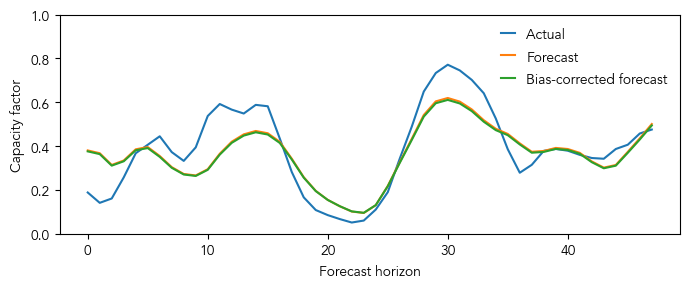

In [22]:
day = 100
hour = 1
asset = 4

plt.figure(figsize=(7, 3))

plt.plot(ac_[day, hour, 24:, asset], label="Actual")
plt.plot(fc_[day, hour, :, asset], label="Forecast")
plt.plot(fc_unbiased_[day, hour, :, asset], label="Bias-corrected forecast")

plt.ylim(0, 1)
plt.xlabel("Forecast horizon")
plt.ylabel("Capacity factor")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [23]:
# zone = 1
# print(ac_.shape, fc_.shape)
# x_ = np.arange(72)

# range_ = [0, 175, 350, 525, 700, 875, 1050]
# for k in range(len(range_) - 1):
#     print(range_[k], range_[k + 1])

#     plt.figure()
#     for hour in range(24):
#         ac_p_ = ac_[range_[k]:range_[k + 1], hour, 24:, zone]
#         fc_p_ = fc_[range_[k]:range_[k + 1], hour, :, zone]
#         B_ = ac_p_ - fc_p_
#         b_ = np.mean(B_, axis = 0)
        
#         plt.plot(x_[hour:hour + 48], b_)
    
#     plt.show()

In [35]:
_DATA = {'Graph': adjacent_regions_,
         'Dataset': {}}

for region in _DATA['Graph'].keys():
    edges_ = _DATA['Graph'][region]['Graph']
    order_ = _DATA['Graph'][region]['Order']
    print(region, edges_, order_)

    E_dt_ = np.stack([dt_fc_ for i in edges_])
    F_dt_ = np.stack([dt_ac_ for i in edges_])
    E_dt_ = np.swapaxes(E_dt_, 0, 1)
    F_dt_ = np.swapaxes(F_dt_, 0, 1)
    print(E_dt_.shape, F_dt_.shape)

    Z_ = np.stack([fc_unbiased_[..., i] for i in edges_])
    E_ = np.stack([fc_[..., i] for i in edges_])
    F_ = np.stack([ac_[..., i] for i in edges_])
    Z_ = np.swapaxes(Z_, 0, 1)
    E_ = np.swapaxes(E_, 0, 1)
    F_ = np.swapaxes(F_, 0, 1)
    print(F_.shape, E_.shape, Z_.shape)

    x_ = np.stack([np.ones(dt_ac_.shape[0])*i for i in edges_])
    y_ = np.stack([np.ones(dt_ac_.shape[0])*i for i in order_])
    X_ = np.stack([x_, y_]).T
    print(x_.shape, y_.shape, X_.shape)
    

    _DATA['Dataset'][region] = {'datetime_actuals': F_dt_,
                                'actuals': F_, 
                                'datetime_forecasts': E_dt_,
                                'forecasts': E_,
                                'unbiased_forecasts': Z_,
                                'neighbors': X_}
    
    print(_DATA['Dataset'][region].keys())
    
# save data in pickle
with open(path_to_data + "/gridstatus/processed_ERCOT_wind_data_v4.pkl", "wb") as f:
    pickle.dump(_DATA, f)

Coastal [0, 1, 3] [0, 2, 1]
(1018, 3, 24, 48) (1018, 3, 24, 72)
(1018, 3, 24, 72) (1018, 3, 24, 48) (1018, 3, 24, 48)
(3, 1018) (3, 1018) (1018, 3, 2)
dict_keys(['datetime_actuals', 'actuals', 'datetime_forecasts', 'forecasts', 'unbiased_forecasts', 'neighbors'])
North [0, 1, 2, 3, 4] [2, 0, 2, 2, 1]
(1018, 5, 24, 48) (1018, 5, 24, 72)
(1018, 5, 24, 72) (1018, 5, 24, 48) (1018, 5, 24, 48)
(5, 1018) (5, 1018) (1018, 5, 2)
dict_keys(['datetime_actuals', 'actuals', 'datetime_forecasts', 'forecasts', 'unbiased_forecasts', 'neighbors'])
Panhandle [1, 2, 4] [2, 0, 1]
(1018, 3, 24, 48) (1018, 3, 24, 72)
(1018, 3, 24, 72) (1018, 3, 24, 48) (1018, 3, 24, 48)
(3, 1018) (3, 1018) (1018, 3, 2)
dict_keys(['datetime_actuals', 'actuals', 'datetime_forecasts', 'forecasts', 'unbiased_forecasts', 'neighbors'])
South [0, 1, 3, 4] [1, 2, 0, 1]
(1018, 4, 24, 48) (1018, 4, 24, 72)
(1018, 4, 24, 72) (1018, 4, 24, 48) (1018, 4, 24, 48)
(4, 1018) (4, 1018) (1018, 4, 2)
dict_keys(['datetime_actuals', 'actuals',

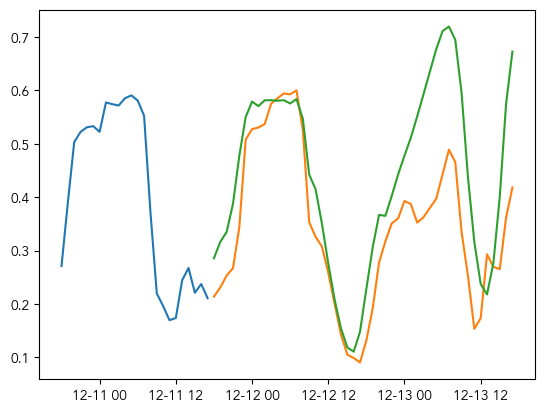

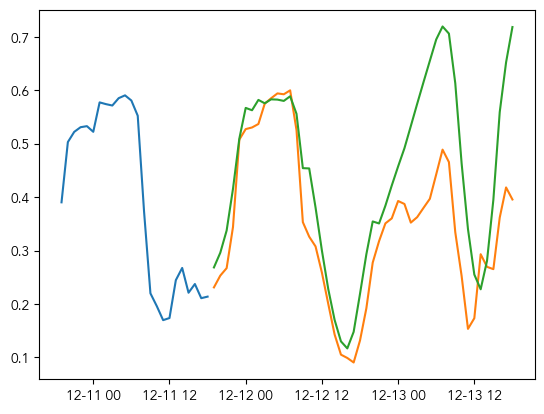

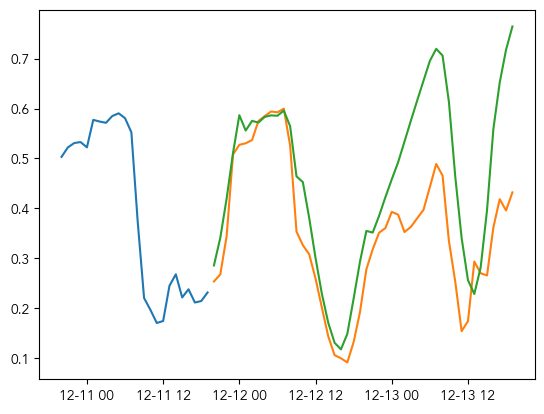

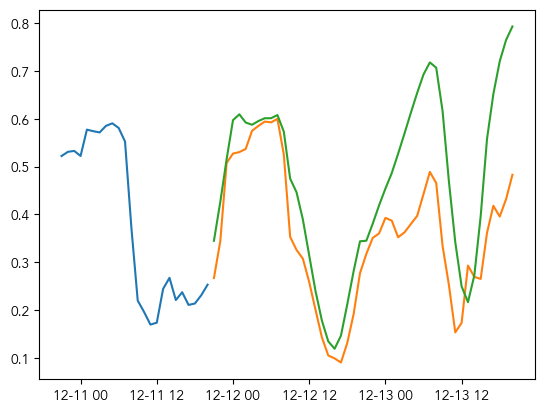

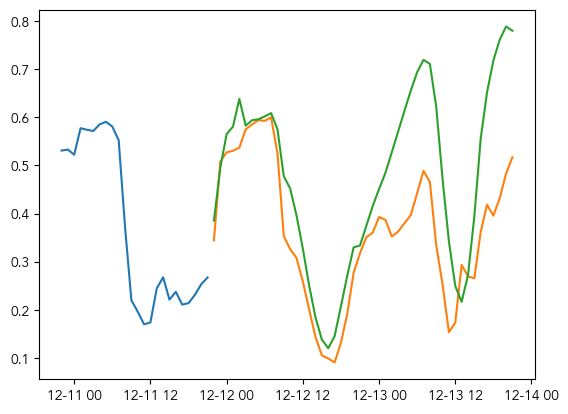

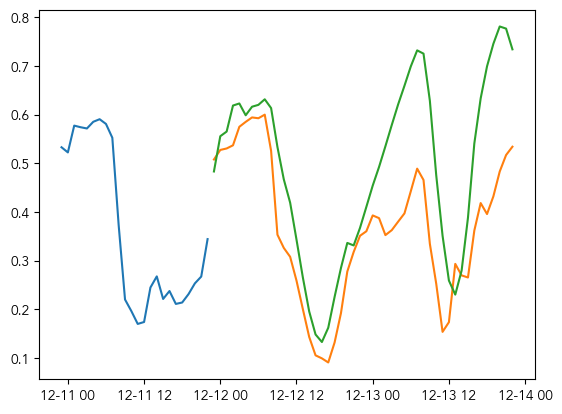

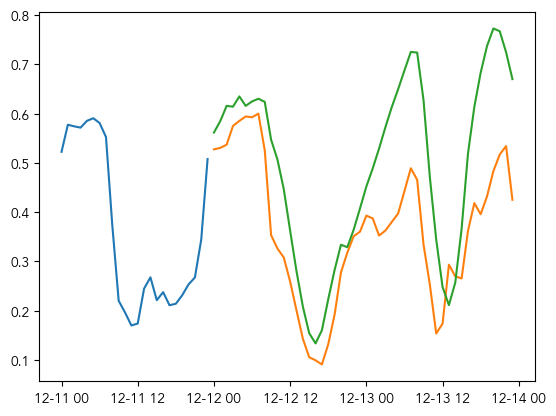

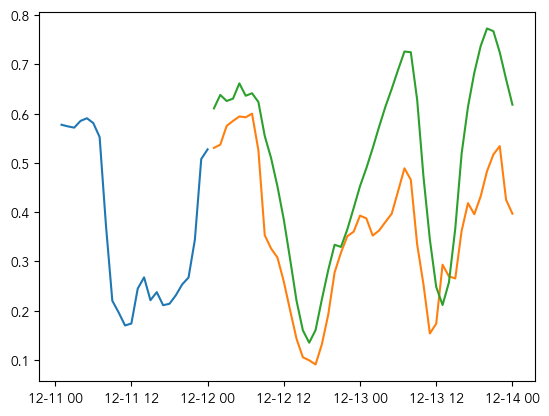

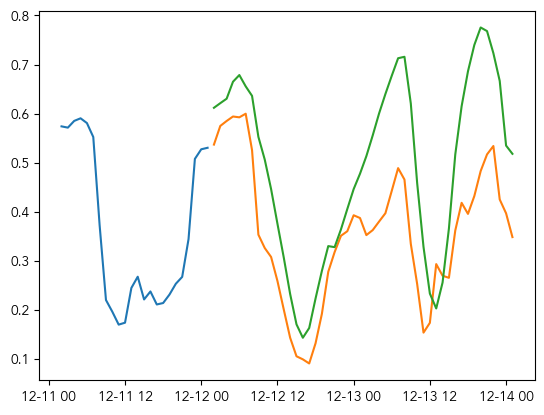

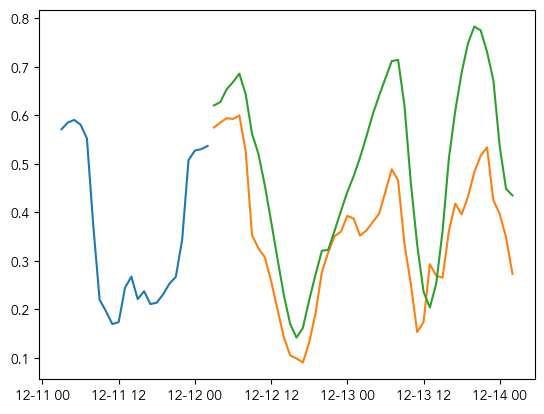

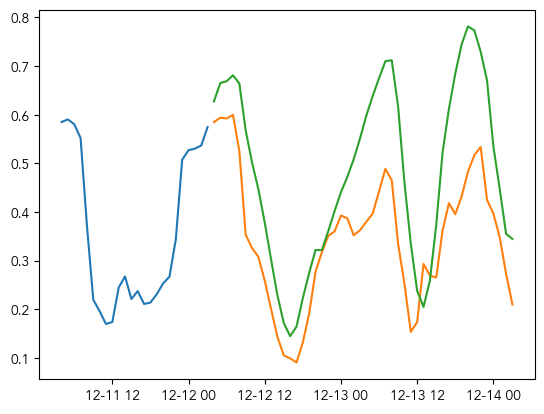

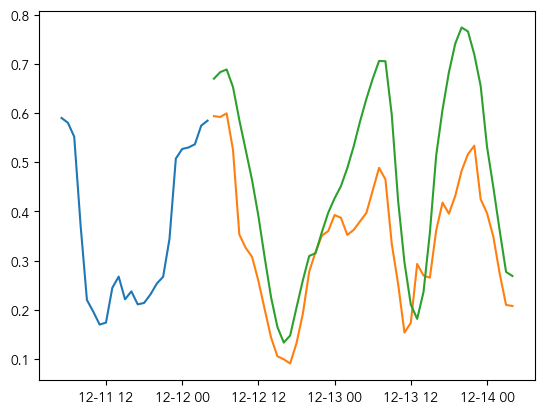

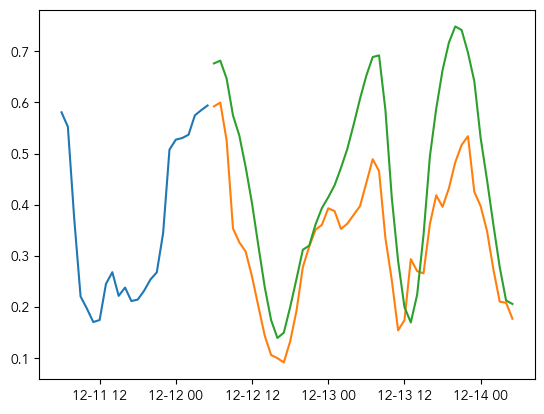

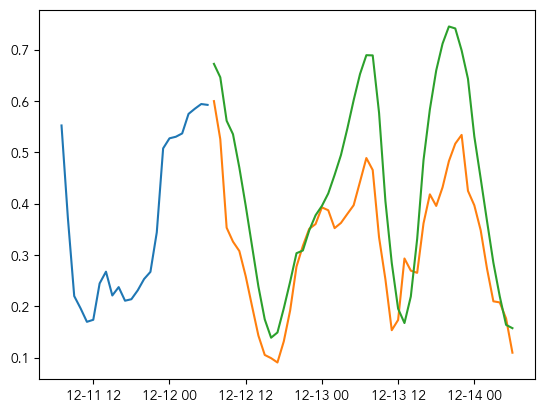

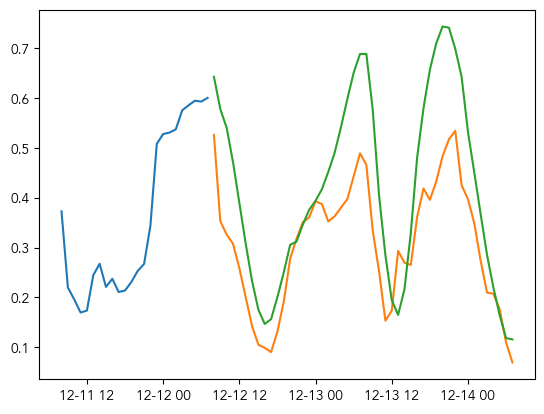

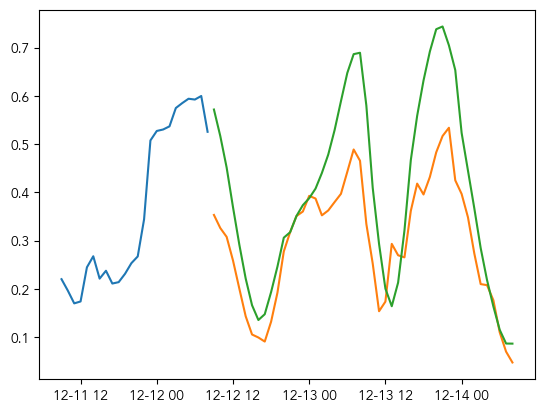

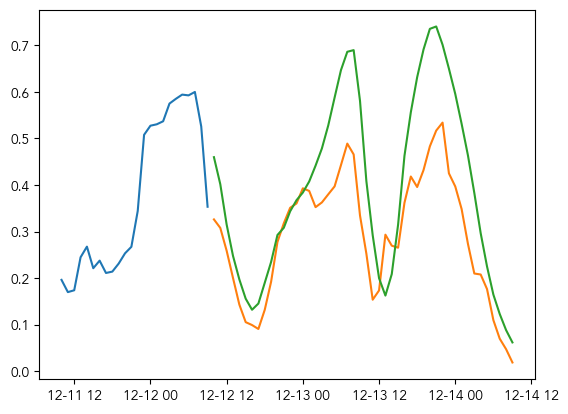

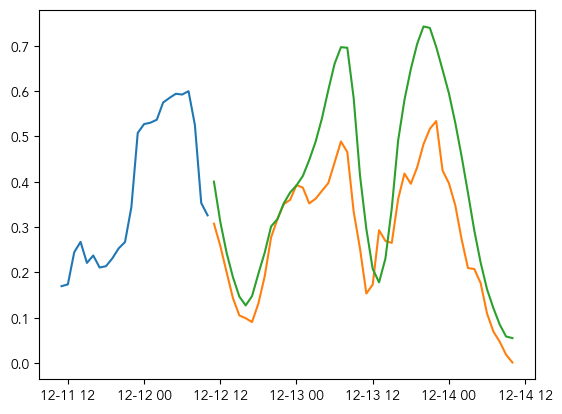

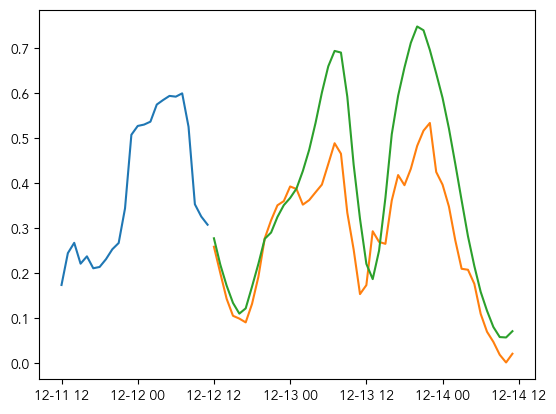

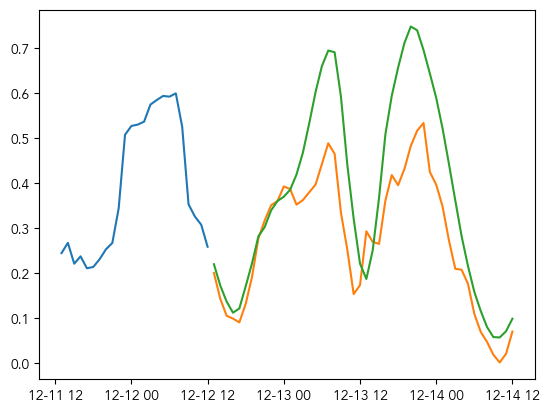

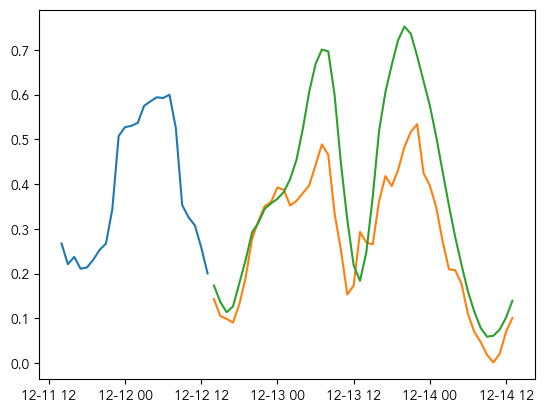

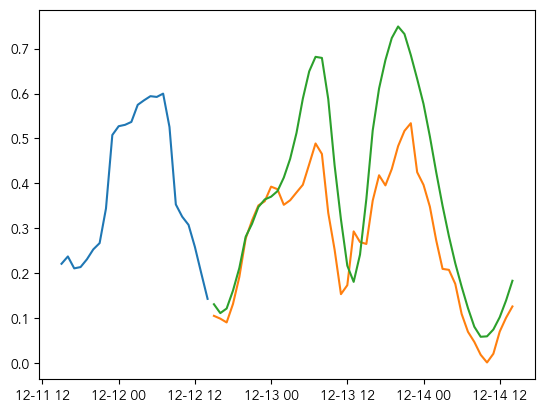

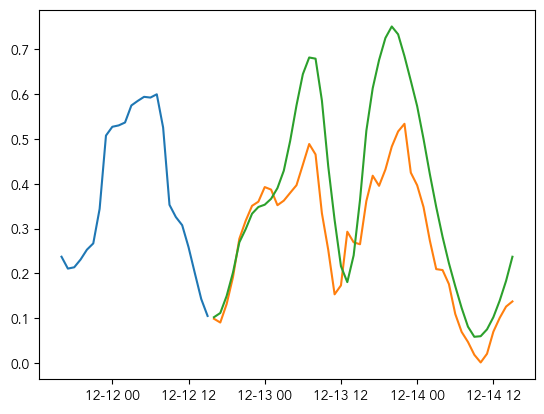

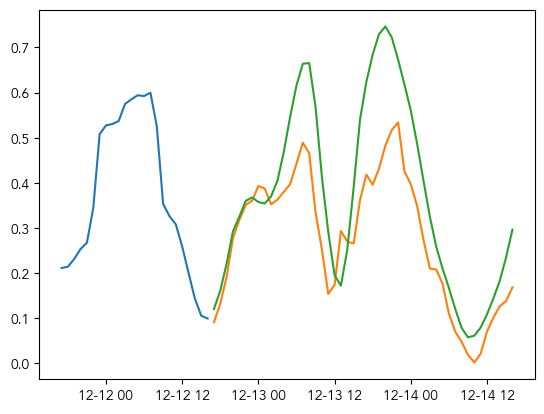

In [128]:
day = 1000
zone = 0

for hour in range(24):
    plt.figure()
    plt.plot(dt_ac_[day, hour, :24], ac_[day, hour, :24, zone])
    plt.plot(dt_ac_[day, hour, 24:], ac_[day, hour, 24:, zone])
    plt.plot(dt_fc_[day, hour, :], fc_[day, hour, :, zone])
    plt.show()

In [ ]:


# df_['year'] = df_['publish_time_local'].dt.year
# df_['year_day'] = df_['publish_time_local'].dt.dayofyear
# df_['hour'] = df_['publish_time_local'].dt.hour
# print(df_)

# check = df_.groupby(['year', 'year_day']).size() == 24*48
# df_ = df_.set_index(['year', 'year_day']).loc[check[check].index].reset_index(drop = False)
# print(df_.shape)

# data_p_ = []
# for year in df_['year'].unique():
#     print(year)
#     for year_day in df_.loc[df_['year'] == year, 'year_day'].unique():
#         data_ = []
#         for hour in range(24):
#             idx_ = (df_['year'] == year) & (df_['year_day'] == year_day) & (df_['hour'] == hour)
#             x_ = df_.loc[idx_, ['interval_start_local',
#                                 'stwpf_panhandle', 
#                                 'stwpf_coastal',
#                                 'stwpf_south',
#                                 'stwpf_west',
#                                 'stwpf_north',
#                                 'gen_panhandle',
#                                 'gen_coastal',
#                                 'gen_south',
#                                 'gen_west',
#                                 'gen_north']].to_numpy()

            
#             if x_.shape[0] != 48.:
#                 print(year, year_day, hour, x_.shape)
#             else:
#                 data_.append(x_)
                
#         x_ = np.stack(data_)

#         if x_.shape[0] != 24.:
#             print(year, year_day, x_.shape)
#         else:
#             data_p_.append(x_)

# x_  = np.stack(data_p_)
# dt_ = x_[..., 0]
# fc_ = x_[..., [1, 2, 3, 4, 5]]
# ac_ = x_[..., [6, 7, 8, 9, 10]]
# print(x_.shape, dt_.shape, fc_.shape, ac_.shape)


In [279]:
# common_dt_ = np.intersect1d(dt_fc_[:, 0, 0], dt_ac_[:, 0, 0])

# idx_fc_ = np.isin(dt_fc_[:, 0, 0], common_dt_)
# idx_ac_ = np.isin(dt_ac_[:, 0, 0], common_dt_)
                  
# dt_fc_ = dt_fc_[idx_fc_, ...]
# dt_ac_ = dt_ac_[idx_ac_, ...]
# print(dt_fc_.shape, dt_ac_.shape)

# fc_ = fc_[idx_fc_, ...]
# ac_ = ac_[idx_ac_, ...]
# print(fc_.shape, ac_.shape)

# _DATA = {'Graph': adjacent_regions_,
#          'Dataset': {}}

# for region in _DATA['Graph'].keys():
#     edges_ = _DATA['Graph'][region]['Graph']
#     order_ = _DATA['Graph'][region]['Order']
#     print(region, edges_, order_)

#     E_dt_ = np.concatenate([dt_fc_ for i in edges_], axis = 0)
#     F_dt_ = np.concatenate([dt_ac_ for i in edges_], axis = 0)
#     print(E_dt_.shape, F_dt_.shape)

#     E_ = np.concatenate([fc_[..., i] for i in edges_], axis = 0)
#     F_ = np.concatenate([ac_[..., i] for i in edges_], axis = 0)
#     print(F_.shape, E_.shape)

#     x_ = np.concatenate([np.ones(dt_ac_.shape[0])*i for i in edges_], axis = 0)
#     y_ = np.concatenate([np.ones(dt_ac_.shape[0])*i for i in order_], axis = 0)
#     X_ = np.stack([x_, y_]).T
#     print(x_.shape, y_.shape, X_.shape)

#     _DATA['Dataset'][region] = {'datetime_actuals': F_dt_,
#                                 'actuals': F_, 
#                                 'datetime_forecasts': E_dt_,
#                                 'forecasts': E_,
#                                 'neighbors': X_}
    
#     print(_DATA['Dataset'][region].keys())

# # save data in pickle
# with open(path_to_data + "/gridstatus/processed_ERCOT_wind_data.pkl", "wb") as f:
#     pickle.dump(_DATA, f)

(1028, 24, 48) (1028, 24, 72)
(1028, 24, 48, 5) (1028, 24, 72, 5)
Coastal [0, 1, 3] [0, 2, 1]
(3084, 24, 48) (3084, 24, 72)
(3084, 24, 72) (3084, 24, 48)
(3084,) (3084,) (3084, 2)
dict_keys(['datetime_actuals', 'actuals', 'datetime_forecasts', 'forecasts', 'neighbors'])
North [0, 1, 2, 3, 4] [2, 0, 2, 2, 1]
(5140, 24, 48) (5140, 24, 72)
(5140, 24, 72) (5140, 24, 48)
(5140,) (5140,) (5140, 2)
dict_keys(['datetime_actuals', 'actuals', 'datetime_forecasts', 'forecasts', 'neighbors'])
Panhandle [1, 2, 4] [2, 0, 1]
(3084, 24, 48) (3084, 24, 72)
(3084, 24, 72) (3084, 24, 48)
(3084,) (3084,) (3084, 2)
dict_keys(['datetime_actuals', 'actuals', 'datetime_forecasts', 'forecasts', 'neighbors'])
South [0, 1, 3, 4] [1, 2, 0, 1]
(4112, 24, 48) (4112, 24, 72)
(4112, 24, 72) (4112, 24, 48)
(4112,) (4112,) (4112, 2)
dict_keys(['datetime_actuals', 'actuals', 'datetime_forecasts', 'forecasts', 'neighbors'])
West [1, 2, 3, 4] [2, 1, 1, 0]
(4112, 24, 48) (4112, 24, 72)
(4112, 24, 72) (4112, 24, 48)
(4112,)

In [ ]:
# # Extract date (UTC-safe)
# df_ = pd.DataFrame({"time": pd.to_datetime(dt_[:, 0])})
# df_["date"] = df_["time"].dt.floor("D")

# # Keep only full days (24 hours)
# counts_ = df_.groupby("date").size()
# index_ = df_["date"].isin(counts_[counts_ == n_day_hours].index)

# dt_ = dt_[index_, :].reshape(-1, n_day_hours, n_horizon_hours)
# ac_ = ac_[index_, :].reshape(-1, n_day_hours, n_horizon_hours, n_regions)
# print(dt_.shape, ac_.shape)

# # Extract date (UTC-safe)
# df_ = pd.DataFrame({"time": pd.to_datetime(dt_[:, 0])})
# df_["date"] = df_["time"].dt.floor("D")

# # Keep only full days (24 hours)
# counts_ = df_.groupby("date").size()
# index_ = df_["date"].isin(counts_[counts_ == n_day_hours].index)

# dt_ = dt_[index_, :].reshape(-1, n_day_hours, n_horizon_hours)
# fc_ = fc_[index_, :].reshape(-1, n_day_hours, n_horizon_hours, n_regions)
# print(dt_.shape, fc_.shape)

In [15]:
# # Formating actual generation structure

# lag = 24
# lead = 48
# AC_ = []
# DT_ac_ = []
# for t in range(dt_.shape[0]):
#     x_ = dt_[t - lag:t + lead]
#     y_ = ac_[t - lag:t + lead, :]

#     if x_.shape[0] == (lag + lead):
#         AC_.append(y_)
#         DT_ac_.append(x_)

# DT_ac_ = np.stack(DT_ac_)
# AC_ = np.stack(AC_)
# print(DT_ac_.shape, AC_.shape)
# print(DT_ac_[0, 0], DT_ac_[-1, -1])

# # Put into DataFrame
# df_ = pd.DataFrame({"time": pd.to_datetime(DT_ac_[:, 0])})

# # Extract date (UTC-safe)
# df_["date"] = df_["time"].dt.floor("D")

# # Count hours per day
# counts = df_.groupby("date").size()

# # Keep only full days (24 hours)
# valid_days = counts[counts == 24].index
# idx_ = df_["date"].isin(valid_days)

# # Filter
# DT_ac_clean_ = DT_ac_[idx_, :].reshape(-1, 24, 72)
# AC_clean_ = AC_[idx_, :].reshape(-1, 24, 72, 5)
# print(DT_ac_clean_.shape, AC_clean_.shape)

(26233, 72) (26233, 72, 5)
2023-01-01 00:00:00+00:00 2025-12-31 23:00:00+00:00
(1093, 24, 72) (1093, 24, 72, 5)


In [16]:
# # Ensure actuals and forecasts sets have the same samples

# DT_ac_clean_prime_ = DT_ac_clean_[..., -48:]
# print(DT_ac_clean_prime_.shape, DT_fc_clean_.shape)

# idx_ac_ = []
# idx_fc_ = []
# for i in range(DT_fc_clean_.shape[0]):
#     dt_fc_ = pd.to_datetime(DT_fc_clean_[i, 0, -1]).to_numpy()

#     for j in range(DT_ac_clean_prime_.shape[0]):
#         dt_ac_ = pd.to_datetime(DT_ac_clean_prime_[j, 0, -1]).to_numpy()

#         if np.isin(dt_fc_, dt_ac_).all():
#             idx_fc_.append(i)
#             idx_ac_.append(j)
#             break

# idx_ac_ = np.array(idx_ac_)
# idx_fc_ = np.array(idx_fc_)
# print(idx_ac_.shape, idx_fc_.shape)

(1093, 24, 48) (406, 24, 48)
(405,) (405,)


In [28]:
# _DATA = {'Graph': adjacent_regions_,
#          'Dataset': {}}

# for region in _DATA['Graph'].keys():
#     edges_ = _DATA['Graph'][region]['Graph']
#     order_ = _DATA['Graph'][region]['Order']
#     print(region, edges_, order_)

#     dt_ac_ = np.concatenate([DT_ac_clean_[idx_ac_, ...] for i in edges_], axis = 0)
#     dt_fc_ = np.concatenate([DT_fc_clean_[idx_fc_, ...] for i in edges_], axis = 0)
#     print(dt_ac_.shape, dt_fc_.shape)
    
#     F_ac_ = np.concatenate([AC_clean_[idx_ac_, ..., i] for i in edges_], axis = 0)
#     E_fc_ = np.concatenate([FC_clean_[idx_fc_,..., i] for i in edges_], axis = 0)
#     print(F_ac_.shape, E_fc_.shape)

#     x_ = np.concatenate([np.ones(DT_ac_clean_[idx_ac_, ...].shape[0])*i for i in edges_], axis = 0)
#     y_ = np.concatenate([np.ones(DT_ac_clean_[idx_ac_, ...].shape[0])*i for i in order_], axis = 0)
#     X_ = np.stack([x_, y_]).T
#     print(X_.shape)

#     _DATA['Dataset'][region] = {'datetime_actuals': dt_ac_,
#                      'actuals': F_ac_, 
#                      'datetime_forecasts': dt_fc_,
#                      'forecasts': E_fc_,
#                      'neighbors': X_}
#     print(_DATA['Dataset'][region].keys())

# # save
# with open(path_to_data + "/gridstatus/processed_ERCOT_wind_data.pkl", "wb") as f:
#     pickle.dump(_DATA, f)

Coastal [0, 1, 3] [0, 2, 1]
(1215, 24, 72) (1215, 24, 48)
(1215, 24, 72) (1215, 24, 48)
(1215, 2)
dict_keys(['datetime_actuals', 'actuals', 'datetime_forecasts', 'forecasts', 'neighbors'])
North [0, 1, 2, 3, 4] [2, 0, 2, 2, 1]
(2025, 24, 72) (2025, 24, 48)
(2025, 24, 72) (2025, 24, 48)
(2025, 2)
dict_keys(['datetime_actuals', 'actuals', 'datetime_forecasts', 'forecasts', 'neighbors'])
Panhandle [1, 2, 4] [2, 0, 1]
(1215, 24, 72) (1215, 24, 48)
(1215, 24, 72) (1215, 24, 48)
(1215, 2)
dict_keys(['datetime_actuals', 'actuals', 'datetime_forecasts', 'forecasts', 'neighbors'])
South [0, 1, 3, 4] [1, 2, 0, 1]
(1620, 24, 72) (1620, 24, 48)
(1620, 24, 72) (1620, 24, 48)
(1620, 2)
dict_keys(['datetime_actuals', 'actuals', 'datetime_forecasts', 'forecasts', 'neighbors'])
West [1, 2, 3, 4] [2, 1, 1, 0]
(1620, 24, 72) (1620, 24, 48)
(1620, 24, 72) (1620, 24, 48)
(1620, 2)
dict_keys(['datetime_actuals', 'actuals', 'datetime_forecasts', 'forecasts', 'neighbors'])
